<a href="https://colab.research.google.com/github/pikey-msc/RiesgosFinancieros/blob/master/2027-1/OpcionesTasa_capfloor_1flujo_con_sup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧮 Opciones sobre Tasa de Interés: Cap / Floor de un solo flujo

**Riesgos Financieros — 2026-1**

Un **cap** (o un **floor**) sobre tasa de interés es una opción sobre una tasa de referencia (en México, la TIIE): protege a quien lo compra de que la tasa suba (cap) o baje (floor) más allá de un nivel pactado (*strike*). Este cuaderno valúa una pequeña cartera de estas opciones — cada una con **un solo flujo** (un "caplet" o "floorlet") — con la fórmula de **Black-76**.

### 🗺️ Ruta del cuaderno
1. **Marco teórico** — qué es un caplet/floorlet, la fórmula de Black-76 aplicada a tasas, y de dónde sale la tasa forward que se usa como "subyacente".
2. **Parámetros** — todo configurable con campos de formulario 📋: las **rutas de los archivos** de curvas (descuento, tasa de referencia y volatilidad) y las características de cada opción de la cartera.
3. **Carga e interpolación de curvas**.
4. **Visualización** de las curvas interpoladas.
5. **Valuación**.
6. **Sensibilidad** — cómo cambia el valor de cada opción si cambia la tasa subyacente o la volatilidad.

> ⚡ **Sobre la eficiencia:** la versión original interpolaba las tres curvas para **todas** las fechas históricas de los archivos, aunque solo la cotización más reciente se usa para valuar — el resto se calculaba y se descartaba. Aquí se interpola únicamente lo que realmente se necesita.

**Cómo usarlo:** ejecuta todo con *Entorno de ejecución → Ejecutar todas* la primera vez; después cambia cualquier campo de formulario (incluidas las rutas de archivo) y vuelve a ejecutar desde ahí hacia abajo.


In [1]:
# @title 📦 Clonar el repositorio del curso (datos e insumos) { display-mode: "form" }
!rm -rf RiesgosFinancieros
!git clone "https://github.com/pikey-msc/RiesgosFinancieros/"


Cloning into 'RiesgosFinancieros'...
remote: Enumerating objects: 1387, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 1387 (delta 127), reused 68 (delta 68), pack-reused 1207 (from 2)
Receiving objects: 100% (1387/1387), 73.04 MiB | 8.49 MiB/s, done.
Resolving deltas: 100% (861/861), done.
Updating files: 100% (479/479), done.


## 🧮 Marco teórico: caplets y floorlets (Black-76)

Un caplet paga, al final de su periodo de referencia, la diferencia positiva entre la tasa observada $S$ y el *strike* $K$ (un floorlet paga $\max(K-S,0)$ en su lugar):

$$ \text{Pago} = N\cdot\max(\phi\cdot(S-K),\,0)\cdot\frac{p_r}{d_{base}} \qquad \phi=\begin{cases}+1 & \text{cap}\\-1 & \text{floor}\end{cases} $$

Como hoy no sabemos cuál será $S$ al vencimiento, se valúa como una opción sobre esa tasa con la fórmula de **Black-76** (Black sobre el *forward*, no sobre el spot):

$$ V = \phi\cdot\Big[S\cdot N(\phi\, d_1) - K\cdot N(\phi\, d_2)\Big]\cdot DF_t\cdot\frac{p_r}{d_{base}}\cdot\frac{1}{1+S\cdot p_r/d_{base}} $$

$$ d_1=\frac{\ln(S/K)+\sigma^2 t/2}{\sigma\sqrt{t}} \qquad d_2 = d_1-\sigma\sqrt{t} $$

Donde $t$ es el plazo al vencimiento del flujo, $\sigma$ la volatilidad de $S$, $DF_t$ el factor de descuento al plazo $t$, $p_r$ el plazo de referencia del cupón (p. ej. 28 días) y $d_{base}$ la base de días. El factor final $1/(1+S\cdot p_r/d_{base})$ es un ajuste de mercado porque el cupón de TIIE se **paga por anticipado** (se descuenta un periodo más de lo habitual).

El parámetro `cs_oir` decide **cómo se anualiza y descuenta**: con tasas *continuas* (`cs_oir=1`) se usa base 365 para $t$ y $\sigma\sqrt t$, y $DF_t$ se obtiene componiendo la tasa de descuento de forma continua; con tasas *simples* (`cs_oir=0`) se usa base 360 y $DF_t=1/(1+d\cdot t/360)$ directamente.

### ¿De dónde sale la tasa "subyacente" $S$?

$S$ no se observa directamente: es la **tasa forward** implícita entre el plazo $t$ (hoy → inicio del periodo de referencia) y $t+p_r$ (hoy → fin), construida igual que en el cuaderno de swaps, a partir de la curva de referencia:

$$ S = \left[\frac{1+t_l\cdot(t+p_r)/360}{1+t_c\cdot t/360} - 1\right]\cdot\frac{360}{p_r} $$

Necesitamos entonces **tres curvas de mercado**: la de **descuento** (para $DF_t$), la de **tasa de referencia** (para construir $S$), y la de **volatilidad** (para $\sigma$).


## 🌐 De curva a superficie de volatilidad (por Delta y por plazo)

Hasta aquí, $\sigma$ salía de una sola **curva** (una tasa de volatilidad por plazo). En el mercado real, la volatilidad implícita también depende de **qué tan dentro o fuera de dinero** está la opción — esto se conoce como *smile* o *skew* de volatilidad. La convención de mercado (sobre todo en FX y tasas) es cotizar ese eje no por *strike*, sino por el **Delta** de la opción: $\Delta = N(\phi\, d_1)$, expresado como porcentaje (0-100).

Este cuaderno usa una **superficie** de volatilidad con dos ejes — **Delta** (bandas: 10, 25, 40, 50, 60, 75, 90) y **plazo** — en vez de una sola curva. La banda **Delta 50** (at-the-money) es la curva de mercado original sin modificar; las demás bandas son una **simulación ilustrativa** de un *smile* típico: más volatilidad lejos de "en dinero", un poco más pronunciado en plazos cortos que en largos, con una leve asimetría (*skew*). *(Ver la celda de "Carga de datos" para el detalle de cómo se construyó.)*

### El problema de la circularidad Delta-Volatilidad

Para saber a qué banda de Delta pertenece una opción necesitamos su Delta... pero el Delta $N(\phi\, d_1)$ depende de $\sigma$, ¡y $\sigma$ es justo lo que estamos buscando en la superficie! Se resuelve con **iteración de punto fijo**, la misma idea que se usa en la práctica de mercado:

1. Se arranca suponiendo Delta = 50 (ATM) para todas las posiciones.
2. Con esa banda se interpola $\sigma$ al plazo de la opción.
3. Con esa $\sigma$ se calcula $d_1$ y el Delta implícito, $N(\phi\, d_1)\cdot 100$.
4. Se busca la banda de Delta más cercana a ese resultado, y se repite desde el paso 2.

En unas pocas vueltas (aquí, 4) el Delta deja de cambiar de banda y el proceso converge.


# 🔧 Funciones auxiliares

In [2]:
# @title Función talamb(): interpolación por "tasa alambrada" { display-mode: "both" }
import numpy as np

def talamb(nodos, curva, plazos):
    """
    Interpola tasas de interés de forma consistente con las tasas forward
    implícitas entre nodos (método "tasa alambrada", estándar del mercado
    mexicano). Fuera del rango de `nodos` se sostiene el valor del nodo más
    cercano (no se extrapola). Alternativa a la interpolación lineal.
    """
    nodos = np.asarray(nodos, dtype=float).flatten()
    curva = np.asarray(curva, dtype=float).flatten()
    plazos = np.asarray(plazos, dtype=float).flatten()

    sorted_indices = np.argsort(nodos)
    nodos_sorted = nodos[sorted_indices]
    curva_sorted = curva[sorted_indices]

    indices = np.searchsorted(nodos_sorted, plazos) - 1
    indices[indices < 0] = 0
    indices[indices >= len(nodos_sorted) - 1] = len(nodos_sorted) - 2

    nodos_i = nodos_sorted[indices]
    nodos_i_plus_1 = nodos_sorted[indices + 1]
    TC_interp = curva_sorted[indices]
    TL_interp = curva_sorted[indices + 1]

    TF = np.where(plazos < nodos_sorted[0], curva_sorted[0],
             np.where(plazos > nodos_sorted[-1], curva_sorted[-1],
                      ((((1 + TL_interp * nodos_i_plus_1 / 360) / (1 + TC_interp * nodos_i / 360)) **
                        ((plazos - nodos_i) / (nodos_i_plus_1 - nodos_i)) *
                        (1 + TC_interp * nodos_i / 360)) - 1) * 360 / plazos))

    return TF


import scipy.stats as stats


def bs_d1(S, K, vol, t, cs_oir):
    """d1 de Black-76 (se reutiliza tanto para el Delta de la opción como
    dentro de opctint, para no repetir la fórmula dos veces)."""
    base_t = 365 if cs_oir == 1 else 360
    return (np.log(S / K) + (vol ** 2) * t / (2 * base_t)) / (vol * np.sqrt(t / base_t))


def delta_pct(S, K, vol, t, cp_oir, cs_oir):
    """
    Delta de un caplet/floorlet, como porcentaje (0-100): N(phi*d1). Se usa
    para elegir la banda de la superficie de volatilidad que le corresponde
    a cada posición (ver Marco teórico: "de curva a superficie").
    """
    phi = (-1) ** (1 - cp_oir)  # cp_oir=1 (cap) -> phi=+1 ; cp_oir=0 (floor) -> phi=-1
    d1 = bs_d1(S, K, vol, t, cs_oir)
    return stats.norm.cdf(d1 * phi) * 100


# 🎛️ Parámetros

Todo lo que se puede ajustar está aquí como **campos de formulario** 📋 — incluidas las **rutas de los archivos** de curvas, que en la versión original estaban fijas en el código. Cambia cualquier valor en el panel de la derecha (o menú ⋮ de la celda → *Mostrar código* para ver/editar el Python) y vuelve a ejecutar el cuaderno desde ahí hacia abajo.


In [3]:
# @title 📂 Parámetros — Rutas de archivos { display-mode: "form" }
btasadesc_oir = "RiesgosFinancieros/2024-1/Tarea/tasa_TIIE_SW_OP.txt"  # @param {type:"string"}
btasaspot_oir = "RiesgosFinancieros/2024-1/Tarea/tasa_DIRS_SW_OP.txt"  # @param {type:"string"}
bvolspot_oir = "RiesgosFinancieros/2024-1/Tarea/tvoltiie_opc_superficie.txt"  # @param {type:"string"}
# btasadesc_oir: curva de descuento  |  btasaspot_oir: curva de tasa de referencia
# bvolspot_oir: SUPERFICIE de volatilidad (columnas DATE, DELTA, y un plazo por columna)


In [4]:
# @title 🧾 Parámetros — Método y cartera de opciones { display-mode: "form" }
import numpy as np

metodo_interpolacion = "Interpolaci\u00F3n lineal"  # @param ["Interpolaci\u00F3n lineal", "Tasa alambrada"]
itpl = 0 if metodo_interpolacion == "Interpolaci\u00F3n lineal" else 1

plazos_oir = [700, 1700, 400, 350, 200]  # @param {type:"raw"}
pr_oir = 28  # @param {type:"integer"}
dct_oir = 360  # @param {type:"integer"}
cp_oir = [1, 0, 0, 0, 0]  # @param {type:"raw"}
K_oir = [0.07, 0.085, 0.078, 0.085, 0.08]  # @param {type:"raw"}
contratos_oir = [2200, -2900, 2900, -460, 5000]  # @param {type:"raw"}
nominal_oir = 1  # @param {type:"number"}
cs_oir = 1  # @param {type:"integer"}
# cp_oir: 1 = cap, 0 = floor  |  cs_oir: 1 = tasa continua, 0 = tasa simple
# pr_oir: plazo de referencia del cup\u00f3n (d\u00edas)  |  dct_oir: base de d\u00edas

plazos_oir = np.array(plazos_oir)
cp_oir = np.array(cp_oir)
K_oir = np.array(K_oir)
contratos_oir = np.array(contratos_oir)

print(f"M\u00e9todo de interpolaci\u00f3n: {metodo_interpolacion}  |  {len(plazos_oir)} posiciones en la cartera")


Método de interpolación: Interpolación lineal  |  5 posiciones en la cartera


# 📥 Carga de datos

Leemos las tres curvas: descuento, tasa de referencia y volatilidad. Cada archivo trae una fila por fecha y una columna por plazo (nodo); esta versión, al valuar en un solo momento, simplemente usa la **fila más reciente disponible** de cada archivo (no filtra por una fecha de valuación específica).

> 🛠️ **Bug encontrado y corregido:** las curvas de descuento y de referencia vienen en el archivo como puntos porcentuales (`8.11` significa `8.11%`), no como decimal. La versión original nunca dividía entre 100, así que las tasas usadas en la valuación quedaban ~100 veces más grandes de lo real (una tasa "forward" calculada saldría de más de 100%, en vez de un dígito). Aquí sí se divide entre 100. La curva de volatilidad **no** se divide, porque ya viene en decimal.


In [5]:
# @title 📥 Lectura de las curvas de mercado { display-mode: "form" }
import pandas as pd

data1 = pd.read_table(btasadesc_oir, header=None)
n1 = data1.shape[0]
m1_orig_oir = len(data1.columns)
x1_orig_oir = pd.DataFrame(data1.iloc[1:n1, 1:m1_orig_oir], dtype=float) / 100  # el archivo trae la tasa en puntos porcentuales (8.11 = 8.11%), no en decimal
nodos1_oir = data1.iloc[0, 1:m1_orig_oir]

data2 = pd.read_table(btasaspot_oir, header=None)
n2 = data2.shape[0]
m2_orig_oir = len(data2.columns)
x2_orig_oir = pd.DataFrame(data2.iloc[1:n2, 1:m2_orig_oir], dtype=float) / 100  # mismo caso que la curva de descuento
nodos2_oir = data2.iloc[0, 1:m2_orig_oir]

# Superficie de volatilidad: columnas DATE, DELTA, y un plazo por columna.
# Se separa en un bloque histórico por banda de Delta (misma cantidad de
# fechas y de nodos de plazo en cada banda).
data3 = pd.read_table(bvolspot_oir, header=0)
data3.columns = [str(c).strip() for c in data3.columns]
nodos_vol = np.array([float(c) for c in data3.columns[2:]])
deltas_disponibles = sorted(data3["DELTA"].unique())
superficie_vol = {
    d: data3.loc[data3["DELTA"] == d].drop(columns=["DATE", "DELTA"]).reset_index(drop=True).astype(float)
    for d in deltas_disponibles
}

print(f"Curva de descuento:      {n1 - 1} fechas, nodos (d\u00edas): {list(nodos1_oir)}")
print(f"Curva de referencia:     {n2 - 1} fechas, nodos (d\u00edas): {list(nodos2_oir)}")
print(f"Superficie de volatilidad: {len(superficie_vol[deltas_disponibles[0]])} fechas por banda, bandas de Delta: {deltas_disponibles}, nodos (d\u00edas): {list(nodos_vol)}")


Curva de descuento:      255 fechas, nodos (días): [np.float64(1.0), np.float64(7.0), np.float64(30.0), np.float64(90.0), np.float64(180.0), np.float64(270.0), np.float64(360.0), np.float64(720.0), np.float64(1080.0), np.float64(1440.0), np.float64(1800.0), np.float64(2160.0), np.float64(2520.0), np.float64(2880.0), np.float64(3240.0), np.float64(3600.0)]
Curva de referencia:     255 fechas, nodos (días): [np.float64(1.0), np.float64(7.0), np.float64(30.0), np.float64(90.0), np.float64(180.0), np.float64(270.0), np.float64(360.0), np.float64(720.0), np.float64(1080.0), np.float64(1440.0), np.float64(1800.0), np.float64(2160.0), np.float64(2520.0), np.float64(2880.0), np.float64(3240.0), np.float64(3600.0)]
Superficie de volatilidad: 255 fechas por banda, bandas de Delta: [np.int64(10), np.int64(25), np.int64(40), np.int64(50), np.int64(60), np.int64(75), np.int64(90)], nodos (días): [np.float64(28.0), np.float64(91.0), np.float64(182.0), np.float64(364.0), np.float64(728.0), np.float64

# 🧮 Interpolación

Interpolamos las tres curvas a los plazos exactos de la cartera — **solo para la cotización más reciente** (fila 0), a diferencia de la versión original, que repetía la interpolación para cada fecha histórica del archivo sin usar el resultado.


In [6]:
# @title 🧮 Interpolación de curvas, tasa forward y superficie de volatilidad { display-mode: "both" }
def approx(x, y, new_x):
    """Interpolaci\u00f3n lineal simple."""
    return np.interp(new_x, x, y)


fila = 0  # se usa la cotizaci\u00f3n m\u00e1s reciente disponible en cada archivo
nodos_desc, curva_desc = np.array(nodos1_oir, dtype=float), np.array(x1_orig_oir.iloc[fila, :], dtype=float)
nodos_ref, curva_ref = np.array(nodos2_oir, dtype=float), np.array(x2_orig_oir.iloc[fila, :], dtype=float)

if itpl == 0:
    x01 = approx(nodos_desc, curva_desc, plazos_oir)          # tasa de descuento al plazo t
    x2tc = approx(nodos_ref, curva_ref, plazos_oir)           # tasa de referencia al plazo t
    x2tl = approx(nodos_ref, curva_ref, plazos_oir + pr_oir)  # tasa de referencia al plazo t + pr_oir
else:
    x01 = talamb(nodos_desc, curva_desc, plazos_oir.astype(float))
    x2tc = talamb(nodos_ref, curva_ref, plazos_oir.astype(float))
    x2tl = talamb(nodos_ref, curva_ref, (plazos_oir + pr_oir).astype(float))

# Tasa forward (subyacente S): tasa de referencia impl\u00edcita entre t y t + pr_oir
x02 = (((1 + x2tl * ((plazos_oir + pr_oir) / 360)) / (1 + x2tc * (plazos_oir / 360))) - 1) * 360 / pr_oir


def resolver_superficie_vol(S, plazos, K, cp, cs, n_iter=4):
    """
    Resuelve, por iteración de punto fijo, la banda de Delta de la
    superficie que le corresponde a cada posición y su volatilidad
    interpolada por plazo dentro de esa banda (ver Marco teórico).
    """
    m = len(plazos)
    delta_guess = np.full(m, 50.0)
    vol = np.zeros(m)
    banda_elegida = np.zeros(m, dtype=int)

    for _ in range(n_iter):
        for j in range(m):
            banda_elegida[j] = min(deltas_disponibles, key=lambda d: abs(d - delta_guess[j]))
            curva_banda = np.array(superficie_vol[banda_elegida[j]].iloc[fila, :], dtype=float)
            plazo_j = np.array([plazos[j]], dtype=float)
            vol[j] = (approx(nodos_vol, curva_banda, plazo_j) if itpl == 0 else talamb(nodos_vol, curva_banda, plazo_j))[0]
        delta_guess = delta_pct(S, K, vol, plazos, cp, cs)

    return vol, banda_elegida, delta_guess


x03, banda_vol, delta_resuelto = resolver_superficie_vol(x02, plazos_oir, K_oir, cp_oir, cs_oir)

resumen_curvas = pd.DataFrame({
    "Plazo (d\u00edas)": plazos_oir,
    "Descuento (%)": np.round(x01 * 100, 4),
    "Subyacente S (%)": np.round(x02 * 100, 4),
    "Strike K (%)": np.round(K_oir * 100, 4),
    "Banda Delta usada": banda_vol,
    "Delta resuelto (%)": np.round(delta_resuelto, 2),
    "Volatilidad (%)": np.round(x03 * 100, 4),
})
resumen_curvas


,Plazo (días),Descuento (%),Subyacente S (%),Strike K (%),Banda Delta usada,Delta resuelto (%),Volatilidad (%)
0,700,8.8285,6.8091,7.0,50,53.77,25.1437
1,1700,9.5802,5.7422,8.5,60,61.92,29.3248
2,400,8.6617,7.4484,7.8,50,53.76,21.3663
3,350,8.6305,7.5964,8.5,60,66.40,21.6725
4,200,8.4814,7.9748,8.0,50,46.62,27.1645


## 👀 Visualicemos la curva de tasas interpolada

Confirma que cada "✕" (interpolado) cae sobre la curva de mercado ("o"/"s"), en el plazo exacto de cada posición de la cartera. La volatilidad tiene su propia visualización más abajo, porque ahora es una superficie (Delta x plazo), no una sola curva.


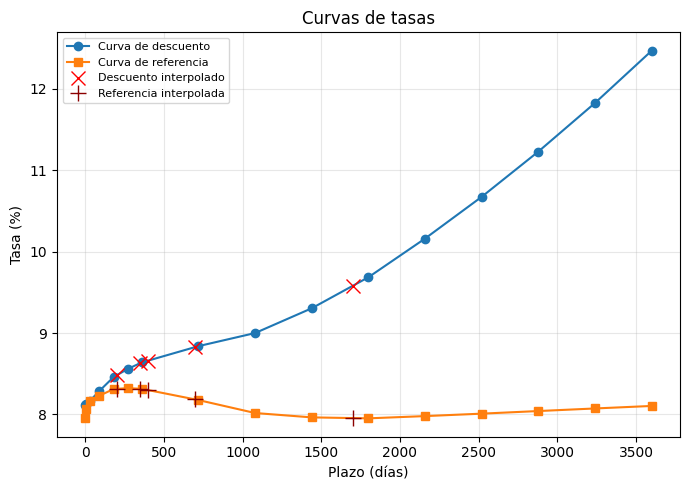

In [7]:
# @title 📈 Curvas de tasas { display-mode: "both" }
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nodos_desc, curva_desc * 100, "o-", label="Curva de descuento")
ax.plot(nodos_ref, curva_ref * 100, "s-", label="Curva de referencia")
ax.plot(plazos_oir, x01 * 100, "x", markersize=10, color="red", label="Descuento interpolado")
ax.plot(plazos_oir, x2tc * 100, "+", markersize=12, color="darkred", label="Referencia interpolada")
ax.set_xlabel("Plazo (d\u00edas)")
ax.set_ylabel("Tasa (%)")
ax.set_title("Curvas de tasas")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 🌐 La superficie completa: smile de volatilidad por Delta

Cada línea es un plazo distinto; el eje horizontal es la banda de Delta (qué tan "en dinero" está la opción). Los puntos marcados son la volatilidad efectivamente usada para cada posición de la cartera, en la banda que le resolvió la iteración.


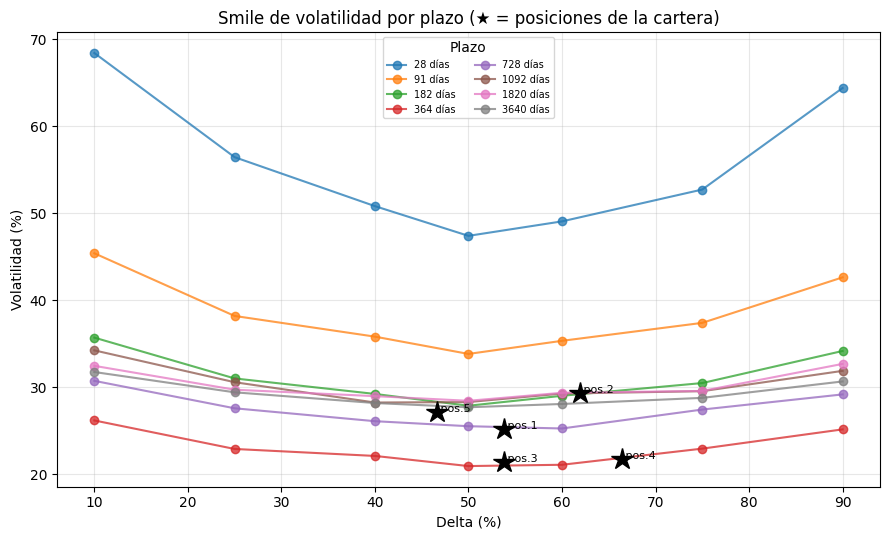

In [8]:
# @title 📈 Superficie de volatilidad (smile por plazo) { display-mode: "both" }
fig, ax = plt.subplots(figsize=(9, 5.5))

for t in nodos_vol:
    curva_t = [np.array(superficie_vol[d].iloc[fila, :], dtype=float)[list(nodos_vol).index(t)] for d in deltas_disponibles]
    ax.plot(deltas_disponibles, np.array(curva_t) * 100, "o-", alpha=0.75, label=f"{int(t)} d\u00edas")

for j in range(len(plazos_oir)):
    ax.plot(delta_resuelto[j], x03[j] * 100, "*", markersize=16, color="black", zorder=5)
    ax.annotate(f" pos.{j + 1}", (delta_resuelto[j], x03[j] * 100), fontsize=8)

ax.set_xlabel("Delta (%)")
ax.set_ylabel("Volatilidad (%)")
ax.set_title("Smile de volatilidad por plazo (\u2605 = posiciones de la cartera)")
ax.legend(fontsize=7, ncol=2, title="Plazo")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 💰 Valuación

Aplicamos la fórmula de Black-76 de la sección de teoría a cada posición de la cartera.



In [9]:
# @title 🧮 Función y valuación: caplet/floorlet (Black-76) { display-mode: "both" }
def opctint(d, S, K_oir, vol, t, cp_oir, cs_oir, pr_oir, dct_oir):
    """
    Valúa un caplet (cp_oir=1) o floorlet (cp_oir=0) de un solo flujo con
    Black-76. `d` es la tasa de descuento simple/continua (ver `cs_oir`),
    `S` la tasa forward subyacente, `vol` la volatilidad (ya resuelta desde
    la superficie por Delta y plazo), `t` el plazo al vencimiento del flujo.
    """
    phi = (-1) ** (1 - cp_oir)  # cp_oir=1 (cap) -> phi=+1 ; cp_oir=0 (floor) -> phi=-1
    base_t = 365 if cs_oir == 1 else 360
    d1 = bs_d1(S, K_oir, vol, t, cs_oir)
    d2 = d1 - vol * np.sqrt(t / base_t)
    if cs_oir == 1:
        vp = np.log(1 + d * t / 360) * 365 / t  # tasa continua equivalente
        DF = np.exp(-vp * t / base_t)
    else:
        vp = d
        DF = 1 / (1 + vp * t / 360)

    payoff = S * stats.norm.cdf(d1 * phi) - K_oir * stats.norm.cdf(d2 * phi)
    ajuste_pago_anticipado = (pr_oir / dct_oir) / (1 + S * pr_oir / dct_oir)
    return payoff * DF * phi * ajuste_pago_anticipado


V0_oir = opctint(x01, x02, K_oir, x03, plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir

resumen_valuacion = pd.DataFrame({
    "Posici\u00f3n": np.arange(1, len(plazos_oir) + 1),
    "Tipo": np.where(cp_oir == 1, "Cap", "Floor"),
    "Plazo (d\u00edas)": plazos_oir,
    "Strike (%)": np.round(K_oir * 100, 4),
    "Subyacente S (%)": np.round(x02 * 100, 4),
    "Banda Delta usada": banda_vol,
    "Contratos": contratos_oir,
    "Valuaci\u00f3n": np.round(V0_oir, 4),
})
resumen_valuacion


,Posición,Tipo,Plazo (días),Strike (%),Subyacente S (%),Banda Delta usada,Contratos,Valuación
0,1,Cap,700,7.0,6.8091,50,2200,1.2520
1,2,Floor,1700,8.5,5.7422,60,-2900,-5.3503
2,3,Floor,400,7.8,7.4484,50,2900,1.7778
3,4,Floor,350,8.5,7.5964,60,-460,-0.4019
4,5,Floor,200,8.0,7.9748,50,5000,2.4078


# 📉 Sensibilidad: tasa subyacente y volatilidad

Dos preguntas típicas de riesgo: *¿cuánto cambia el valor si la tasa subyacente sube o baja?* y *¿cuánto cambia si la volatilidad cambia?* Movemos cada factor alrededor de su valor actual (marcado con una línea punteada) y revaluamos, mantieniendo todo lo demás fijo — exactamente la misma idea de "aislar un factor de riesgo" de los cuadernos de Swaps y de Riesgo Integrado.


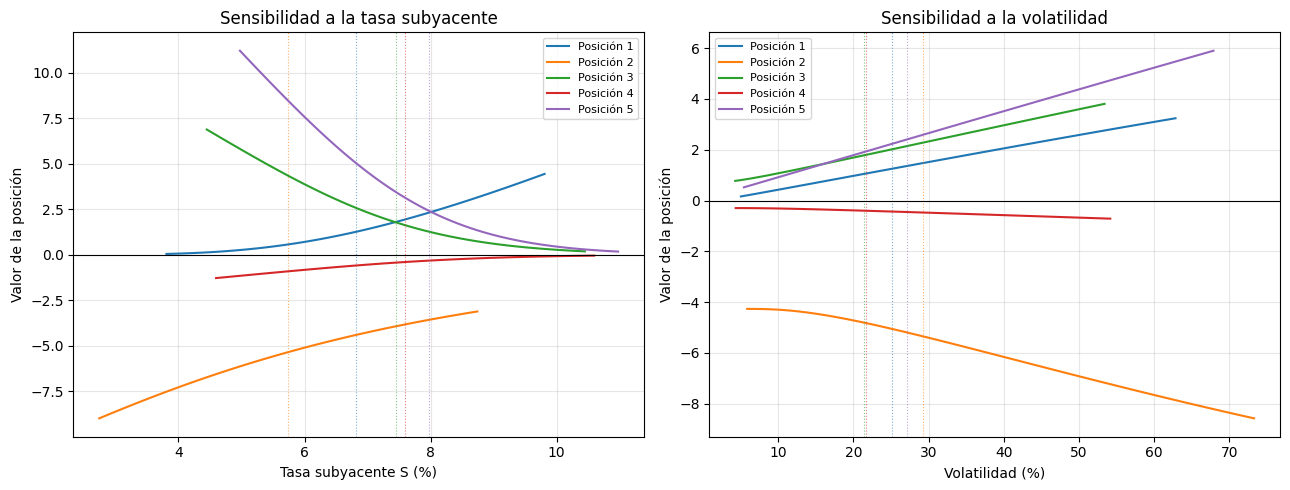

In [10]:
# @title 📉 Perfil de valor vs. tasa subyacente y vs. volatilidad { display-mode: "both" }
n_puntos = 60
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for j in range(len(plazos_oir)):
    rango_S = np.linspace(max(x02[j] - 0.03, 1e-4), x02[j] + 0.03, n_puntos)
    val_S = np.array([
        opctint(x01[j], s, K_oir[j], x03[j], plazos_oir[j], cp_oir[j], cs_oir, pr_oir, dct_oir) * contratos_oir[j] * nominal_oir
        for s in rango_S
    ])
    linea, = axes[0].plot(rango_S * 100, val_S, label=f"Posici\u00f3n {j + 1}")
    axes[0].axvline(x02[j] * 100, color=linea.get_color(), linestyle=":", linewidth=0.8, alpha=0.6)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Tasa subyacente S (%)")
axes[0].set_ylabel("Valor de la posici\u00f3n")
axes[0].set_title("Sensibilidad a la tasa subyacente")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for j in range(len(plazos_oir)):
    rango_vol = np.linspace(max(x03[j] * 0.2, 1e-4), x03[j] * 2.5, n_puntos)
    val_vol = np.array([
        opctint(x01[j], x02[j], K_oir[j], v, plazos_oir[j], cp_oir[j], cs_oir, pr_oir, dct_oir) * contratos_oir[j] * nominal_oir
        for v in rango_vol
    ])
    linea, = axes[1].plot(rango_vol * 100, val_vol, label=f"Posici\u00f3n {j + 1}")
    axes[1].axvline(x03[j] * 100, color=linea.get_color(), linestyle=":", linewidth=0.8, alpha=0.6)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Volatilidad (%)")
axes[1].set_ylabel("Valor de la posici\u00f3n")
axes[1].set_title("Sensibilidad a la volatilidad")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ✅ Glosario y para seguir practicando

### Glosario rápido
- **Cap / Floor:** opción que paga cuando la tasa de referencia sube (cap) o baja (floor) más allá de un strike.
- **Caplet / Floorlet:** un cap o floor de un solo periodo (un solo flujo).
- **Tasa forward:** la tasa implícita entre dos plazos de una curva; aquí funciona como el "subyacente" de la opción.
- **Black-76:** variante de Black-Scholes que valúa la opción sobre el *forward* del subyacente, no sobre su valor spot.
- **Volatilidad:** qué tan incierta es la tasa subyacente al vencimiento; a mayor volatilidad, mayor valor de la opción (para el comprador).

### 🧪 Ejercicios sugeridos
1. Cambia `metodo_interpolacion` a "Tasa alambrada" y compara la tabla de valuación.
2. Sube/baja `K_oir` de una posición: ¿en qué dirección se mueve su valor? ¿Coincide con lo que ves en la gráfica de sensibilidad?
3. Cambia `cs_oir` de 1 a 0 (tasa simple en vez de continua) y observa qué tanto cambia la valuación — debería ser una diferencia pequeña, no un cambio de signo.
4. Cambia una de las rutas de archivo (por ejemplo, a la carpeta `2022-1/Insumos` en vez de `2024-1/Tarea`) y verifica que el cuaderno siga corriendo con las nuevas curvas.
5. Agrega una sexta posición a la cartera (arreglos de 6 elementos en la celda de parámetros) y sigue su efecto en la tabla de valuación y en las gráficas de sensibilidad.
